In [10]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
import pandas as pd
from pathlib import Path
import time

ROOT_PATH = "/bohr/CIFAR10-no-label-test-rigk/v1"

class MyDataset(Dataset):
    def __init__(self, x, y):
        self._x = x
        self._y = y

    @staticmethod
    def _to_chw(image: torch.Tensor) -> torch.Tensor:
        if image.ndim == 1:
            if image.numel() == 28 * 28:
                return image.view(1, 28, 28)
            if image.numel() == 32 * 32:
                return image.view(1, 32, 32)
            if image.numel() == 3 * 32 * 32:
                return image.view(3, 32, 32)
            side = int(image.numel() ** 0.5)
            if side * side == image.numel():
                return image.view(1, side, side)
            raise ValueError(f"Unsupported flat image length: {image.numel()}")

        if image.ndim == 2:
            return image.unsqueeze(0)

        if image.ndim == 3 and image.shape[0] not in (1, 3) and image.shape[-1] in (1, 3):
            return image.permute(2, 0, 1)

        return image

    @staticmethod
    def _preprocess(image: torch.Tensor) -> torch.Tensor:
        # 支持单张图像 [C, H, W] 和批量图像 [B, C, H, W]
        if image.ndim == 4:
            return torch.stack([MyDataset._preprocess(item) for item in image], dim=0)

        image = MyDataset._to_chw(image)

        # 像素值统一到 [0, 1]
        if image.max() > 1.0:
            image = image / 255.0

        # 按通道标准化：1通道走CIFAR10统计量，3通道走CIFAR10统计量
        if image.shape[0] == 1:
            mean = torch.tensor([0.1307], dtype=image.dtype, device=image.device).view(-1, 1, 1)
            std = torch.tensor([0.3081], dtype=image.dtype, device=image.device).view(-1, 1, 1)
        else:
            mean = torch.tensor([0.4914, 0.4822, 0.4465], dtype=image.dtype, device=image.device).view(-1, 1, 1)
            std = torch.tensor([0.2470, 0.2435, 0.2616], dtype=image.dtype, device=image.device).view(-1, 1, 1)

        image = (image - mean) / (std + 1e-8)
        return image

    def __getitem__(self, idx):
        image = torch.tensor(self._x[idx], dtype=torch.float32)
        label = torch.tensor(self._y[idx], dtype=torch.long)

        # 先统一成 [C, H, W]
        image = self._to_chw(image)

        image = self._preprocess(image)
        return image, label

    def __len__(self):
        return len(self._x)

def prepare_data_loader(
    path: str,
    ratio: float = None,
    train_batch_size: int = 1,
    is_train: bool = True,
) -> dict:
    """
    参数:
        path (str): .npz格式的数据集文件路径
        ratio (float): 训练集比例
        train_batch_size (int): 批次大小
        num_workers (int): 数据加载的工作进程数
    返回:
        dict: 包含训练和测试数据加载器的字典
    """
    print("开始加载数据...")  # 添加调试信息
    train_dataset = torch.load(path)
    train_dataset = MyDataset(train_dataset[0], train_dataset[1])
    if is_train:
        train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [int(len(train_dataset) * ratio), len(train_dataset) - int(len(train_dataset) * ratio)])
        train_loader = torch.utils.data.DataLoader(
                                                    dataset=train_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=True,
                                                drop_last=True,
                                                pin_memory=True  
                                                )
        val_loader = torch.utils.data.DataLoader(
                                                dataset=val_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=False,
                                                pin_memory=True  
        )
        print("数据加载器创建完成")  # 添加调试信息

        return {"train": train_loader, "val": val_loader}
    else:
        test_loader = torch.utils.data.DataLoader(
                                                dataset=train_dataset, 
                                                batch_size=train_batch_size, 
                                                shuffle=False,
                                                pin_memory=True  
        )
        print("测试数据加载器创建完成")  # 添加调试信息

        return {"test": test_loader}


In [11]:
class SimpleCNN(nn.Module):
    """
    可配置的CNN模型
    
    参数:
        in_channels (int): 输入通道数
        num_classes (int): 分类类别数
        conv_layers (list): 每个卷积层的输出通道数列表
        fc_layers (list): 每个全连接层的输出维度列表
        kernel_size (int): 卷积核大小
        dropout_rate (float): Dropout比率
    """
    def __init__(
        self,
        in_channels: int = 3,
        num_classes: int = 10,
        conv_layers: list = [32, 64],  # 默认两层卷积
        fc_layers: list = [128, 64],   # 默认两层全连接
        kernel_size: int = 3,
        dropout_rate: float = 0.1
    ):
        super().__init__()
        
        # 构建卷积层
        self.conv_blocks = nn.ModuleList()
        current_channels = in_channels
        
        for i, out_channels in enumerate(conv_layers):
            conv_block = nn.Sequential(
                nn.Conv2d(
                    in_channels=current_channels,
                    out_channels=out_channels,
                    kernel_size=kernel_size,
                    stride=1,
                    padding='same'
                ),
                # nn.BatchNorm2d(out_channels), 可选择是否添加BatchNorm层
                nn.ReLU(),
                nn.MaxPool2d(kernel_size=2)
            )
            self.conv_blocks.append(conv_block)
            current_channels = out_channels
           
            
        # 计算展平后的特征维度
        # 每经过一次MaxPool2d或AvgPool2d，特征图尺寸减半
        feature_size = current_channels * (32 // (2 ** len(conv_layers))) ** 2
        
        # 构建全连接层
        self.fc_blocks = nn.ModuleList()
        current_dim = feature_size
        
        for fc_dim in fc_layers:
            fc_block = nn.Sequential(
                nn.Linear(current_dim, fc_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            )
            self.fc_blocks.append(fc_block)
            current_dim = fc_dim
            
        # 输出层
        self.output_layer = nn.Linear(current_dim, num_classes)

    def forward(self, x):
         # 通过所有卷积层
         for conv_block in self.conv_blocks:
             x = conv_block(x)
    
         # 展平
         x = torch.flatten(x, start_dim=1)
    
         # 通过所有全连接层
         for fc_block in self.fc_blocks:
              x = fc_block(x)
        
         # 输出层
         x = self.output_layer(x)
         return x 
        


In [12]:
import torch.optim as optim
import matplotlib.pyplot as plt
loss_fn = nn.CrossEntropyLoss()
time0 = time.time()
def train_step(
    model: nn.Module, optimizer, batch: dict, device: torch.device
):
    """
    单步训练
    """
    batch_images, labels = batch
    batch_images = batch_images.to(device)
    labels = labels.to(device)
        
    optimizer.zero_grad()

    logits = model(batch_images) # 模型正向过程
        
    loss = loss_fn(logits, labels) # 计算总损失
        
    loss.backward() # 反向传播
        
    torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # 添加梯度裁剪，防止梯度爆炸
        
    optimizer.step()

    return loss.item(), logits, labels
        

def eval_step(model: nn.Module, batch: dict, device: torch.device):
    # 单步评估
    model.eval()
    with torch.no_grad():
        batch_images, labels = batch
        batch_images = batch_images.to(device)
        labels = labels.to(device) 
        logits = model(batch_images) # 模型正向过程
        loss = loss_fn(logits, labels) # 计算总损失
        return loss.item(), logits, labels
    
def train_per_epoch(
    model: nn.Module,
    optimizer: optim.Optimizer,
    batch_size: int,
    train_loader: DataLoader,
    device: torch.device,
    global_batch_offset: int,
):
    model.train()
    num_data = len(train_loader.dataset)
    num_batches = len(train_loader)
    correct = 0
    total_loss = 0
    print(f"开始训练 - 总样本数: {num_data}")
    print(f"总批次数: {len(train_loader)}")

    train_loss_list = []
    train_acc_list = []

    test_loss_list = []
    test_acc_list = []
    test_batch_idx = []
    for batch_idx, batch in enumerate(train_loader):
        loss, logits, labels = train_step(model, optimizer, batch, device)
        total_loss += loss
        
        # 计算当前批次的预测值
        _, predicted = torch.max(logits, 1)
        correct += (predicted == labels).sum().item()
        
        # ✅ 计算当前批次的准确率
        batch_correct = (predicted == labels).sum().item()
        batch_total = len(labels)
        batch_acc = batch_correct / batch_total  # 当前批次的准确率
    
        # 每5个批次打印一次
        if batch_idx % 5 == 0:
            current = batch_idx * batch_size + len(batch[0])
            print(f"批次 {batch_idx} Train: Loss: {loss:>6.4f}, Acc: {100*batch_acc:.4f}%, 进度: {current:>5d}/{num_data:>5d}")            
            print(f"批次 {batch_idx}: Finished in {time.time() - time0:.2f} seconds")
            
        if batch_idx % 15 == 0:
            test_loss, test_acc = val_per_epoch(model, val_loader, device)
            test_loss_list.append(test_loss) 
            test_acc_list.append(test_acc)
            test_batch_idx.append(global_batch_offset + batch_idx)
            print(f"批次 {batch_idx} Val : Loss: {test_loss:>6.4f}, Acc: {100*test_acc:.4f}%")
            print(f"批次 {batch_idx}: Finished in {time.time() - time0:.2f} seconds")
        
        # ✅ 记录每个批次的 loss 和 acc
        train_loss_list.append(loss) 
        train_acc_list.append(batch_acc)
        
    test_loss, test_acc = val_per_epoch(model, val_loader, device)
    test_loss_list.append(test_loss) 
    test_acc_list.append(test_acc)
    test_batch_idx.append(global_batch_offset + batch_idx)
    print(f"批次 {batch_idx} Validation : Loss: {test_loss:>6.4f}, Acc: {100*test_acc:.4f}%")
    print(f"批次 {batch_idx}: Finished in {time.time() - time0:.2f} seconds")
    accuracy = correct / num_data
    avg_loss = total_loss / num_batches
    print(f"Train Error: \n Accuracy: {(100*accuracy):>0.1f}%, Avg loss: {avg_loss:>.8f} \n")
    return train_loss_list, train_acc_list, test_loss_list, test_acc_list, test_batch_idx
        
def val_per_epoch(
    model: nn.Module,
    val_loader: DataLoader,
    device: torch.device,
):
    """
    每轮测试
    """
    model.eval()
    total_loss = 0.0
    correct = 0
    num_batches = len(val_loader)
    num_data = len(val_loader.dataset)
    with torch.no_grad():
        for batch in val_loader:
            loss, logits, labels = eval_step(model, batch, device)
            total_loss += loss
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()

    avg_loss = total_loss / num_batches
    accuracy = correct / num_data
    return avg_loss, accuracy

def draw_loss_accuracy_curves(train_losses, train_acc_list, test_batch_idx_list, test_loss_list, test_acc_list):
    plt.figure(figsize=(18, 5))

    # 绘制 loss 曲线
    plt.subplot(1, 3, 1)
    plt.plot(train_losses, label='Train Loss', alpha=0.5)
    plt.plot(test_batch_idx_list, test_loss_list, label='Validation Loss', marker='o', markersize=3)
    plt.title('Loss vs Batch Index')
    plt.xlabel('Batch Index')
    plt.ylabel('Loss')
    plt.legend()

    # 绘制 train acc 和 val acc
    plt.subplot(1, 2, 2)
    plt.plot(train_acc_list, label='Train Acc', alpha=0.5)
    plt.plot(test_batch_idx_list, test_acc_list, label='Validation Acc', marker='o', markersize=3)
    plt.title('Accuracy vs Batch Index')
    plt.xlabel('Batch Index')
    plt.ylabel('Accuracy')
    plt.legend()

    # # 绘制 validation accuracy 单独
    # plt.subplot(1, 3, 3)
    # plt.plot(test_batch_idx_list, test_acc_list, label='Validation Accuracy', marker='o', markersize=3)
    # plt.title('Validation Accuracy vs Batch Index')
    # plt.xlabel('Batch Index')
    # plt.ylabel('Accuracy')
    # plt.legend()

    plt.tight_layout()
    plt.show()


def controller(
    train_loader,
    val_loader,
    seed: int,
    # CNN特有参数
    in_channels: int = None,
    conv_layers: list = None,
    kernel_size: int = None,
    fc_layers  : list = None,
    # 通用参数
    num_classes: int = 10,
    dropout_rate: float = 0.1,
    ratio: float = 0.8,
    train_batch_size: int = 64,
    num_workers: int = 4,
    epochs: int = 10,
    learning_rate: float = 0.001,
    weight_decay: float = 0.004
):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    torch.manual_seed(seed)
    model = SimpleCNN(
            in_channels=in_channels,
            num_classes=num_classes,
            conv_layers=conv_layers,
            fc_layers=fc_layers,  
            kernel_size=kernel_size,
            dropout_rate=dropout_rate
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    # print(f"Total Epoch: {epochs}")
    best_acc = 0.0
    train_loss_list = []
    train_acc_list = []
    test_loss_list = []
    test_acc_list = []
    test_batch_idx_list = []

    # 初始 validation（对应 batch index 0）
    test_loss, test_acc = val_per_epoch(model, val_loader, device)
    test_loss_list.append(test_loss)
    test_acc_list.append(test_acc)
    test_batch_idx_list.append(0)

    num_batches_per_epoch = len(train_loader)

    for epoch in range(epochs):
        print(f"Epoch {epoch + 1}/{epochs} strated in {time.time() - time0:.2f} seconds")
        global_batch_offset = epoch * num_batches_per_epoch

        train_loss, train_acc, test_loss, test_acc, test_batch_idx = train_per_epoch(
            model, optimizer, train_batch_size, train_loader, device, global_batch_offset
        )
        scheduler.step()
        if test_acc[-1] > best_acc:
            best_acc = test_acc[-1]
            torch.save(model.state_dict(), 'best_model.pth')
        train_loss_list.extend(train_loss)
        train_acc_list.extend(train_acc)
        test_loss_list.extend(test_loss)
        test_acc_list.extend(test_acc)
        test_batch_idx_list.extend(test_batch_idx)
        
        print(f"Epoch {epoch + 1} Finished in {time.time() - time0:.2f} seconds")
        print(f"Validation accuracy: {100*test_acc[-1]:.2f}%")
        draw_loss_accuracy_curves(train_loss_list, train_acc_list, test_batch_idx_list, test_loss_list, test_acc_list)
        
    print(f"Training completed! Best accuracy: {100*best_acc:.2f}%")
    
    return model

def show_sample_images(sample, title):
    images, labels = sample
    images = images.cpu().numpy()
    labels = labels.cpu().numpy()
    
    plt.figure(figsize=(8, 8))
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        if images.shape[1] == 1:  # 灰度图像
            plt.imshow(images[i][0], cmap='gray')
        else:  # 彩色图像
            img = np.transpose(images[i], (1, 2, 0))  # 转换为HWC格式
            img = (img * np.array([0.2470, 0.2435, 0.2616]) + np.array([0.4914, 0.4822, 0.4465])) * 255.0  # 反标准化
            img = np.clip(img.astype(np.uint8), 0, 255)  # 确保像素值在有效范围内
            plt.imshow(img)
        plt.title(f"Label: {labels[i]}")
        plt.axis('off')
    plt.suptitle(title)
    plt.show()

开始加载数据...
数据加载器创建完成


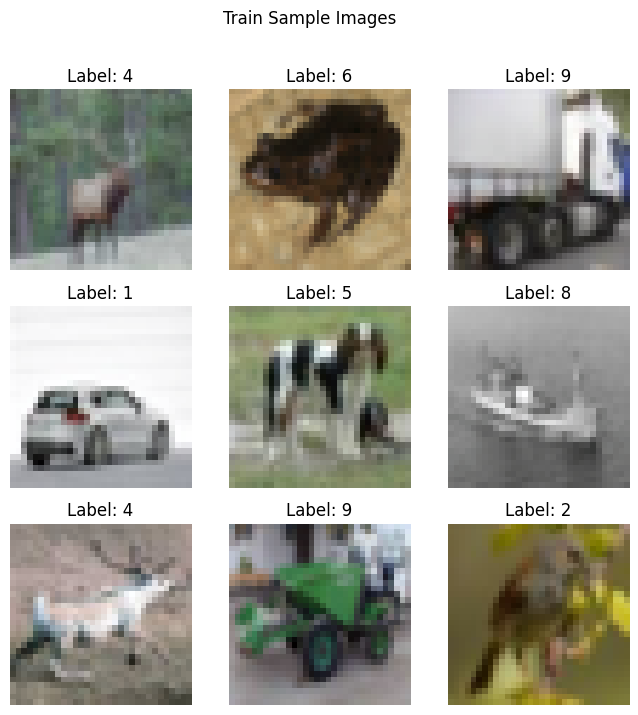

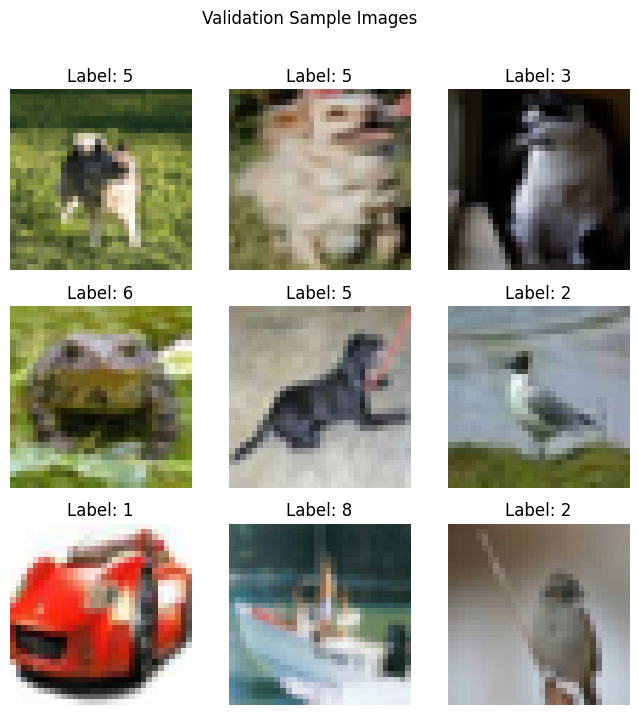

Epoch 1/10 strated in 24.80 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 2.3096, Acc: 12.5000%, 进度:   128/40000
批次 0: Finished in 25.44 seconds
批次 0 Val : Loss: 2.3783, Acc: 9.9700%
批次 0: Finished in 44.34 seconds
批次 5 Train: Loss: 2.2922, Acc: 9.3750%, 进度:   768/40000
批次 5: Finished in 46.85 seconds
批次 10 Train: Loss: 2.3006, Acc: 7.0312%, 进度:  1408/40000
批次 10: Finished in 49.38 seconds
批次 15 Train: Loss: 2.2599, Acc: 15.6250%, 进度:  2048/40000
批次 15: Finished in 51.82 seconds
批次 15 Val : Loss: 2.2468, Acc: 13.4900%
批次 15: Finished in 66.59 seconds
批次 20 Train: Loss: 2.1307, Acc: 17.9688%, 进度:  2688/40000
批次 20: Finished in 69.13 seconds
批次 25 Train: Loss: 2.0648, Acc: 17.1875%, 进度:  3328/40000
批次 25: Finished in 71.64 seconds
批次 30 Train: Loss: 2.0607, Acc: 17.1875%, 进度:  3968/40000
批次 30: Finished in 74.15 seconds
批次 30 Val : Loss: 2.1043, Acc: 15.4700%
批次 30: Finished in 88.94 seconds
批次 35 Train: Loss: 2.0494, Acc: 25.0000%, 进度:  4608/40000
批次 35: Finished in 91.42 secon

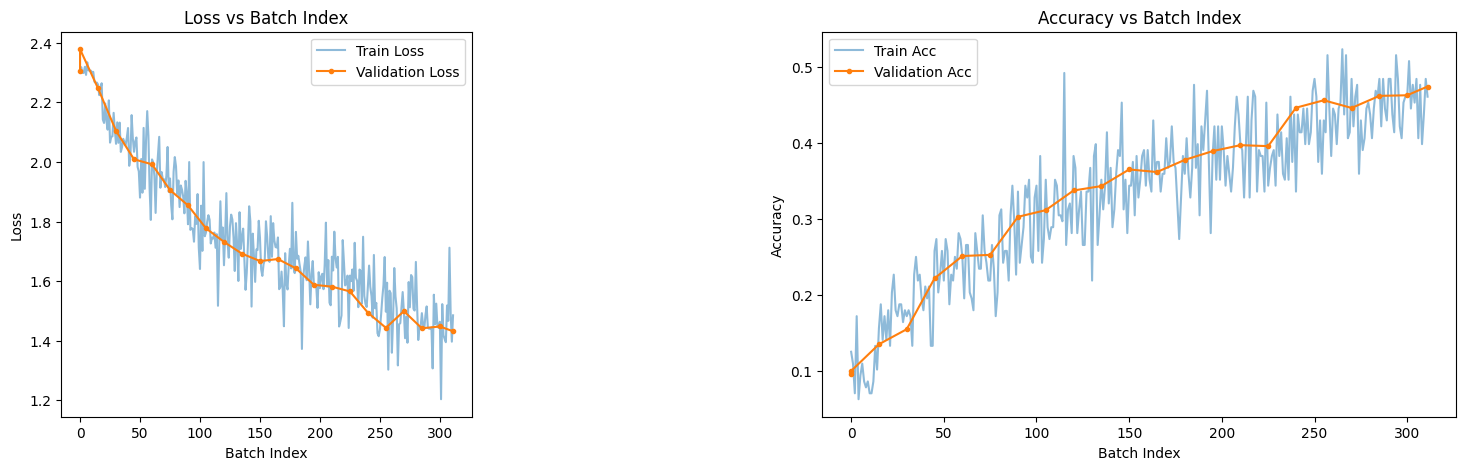

Epoch 2/10 strated in 501.39 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 1.3774, Acc: 48.4375%, 进度:   128/40000
批次 0: Finished in 501.92 seconds
批次 0 Val : Loss: 1.4718, Acc: 46.2000%
批次 0: Finished in 520.24 seconds
批次 5 Train: Loss: 1.3614, Acc: 51.5625%, 进度:   768/40000
批次 5: Finished in 522.87 seconds
批次 10 Train: Loss: 1.2780, Acc: 50.7812%, 进度:  1408/40000
批次 10: Finished in 525.53 seconds
批次 15 Train: Loss: 1.3476, Acc: 52.3438%, 进度:  2048/40000
批次 15: Finished in 528.25 seconds
批次 15 Val : Loss: 1.4016, Acc: 48.5000%
批次 15: Finished in 542.85 seconds
批次 20 Train: Loss: 1.4286, Acc: 45.3125%, 进度:  2688/40000
批次 20: Finished in 545.55 seconds
批次 25 Train: Loss: 1.3222, Acc: 45.3125%, 进度:  3328/40000
批次 25: Finished in 548.07 seconds
批次 30 Train: Loss: 1.3621, Acc: 50.0000%, 进度:  3968/40000
批次 30: Finished in 550.73 seconds
批次 30 Val : Loss: 1.3750, Acc: 48.3100%
批次 30: Finished in 569.07 seconds
批次 35 Train: Loss: 1.4713, Acc: 48.4375%, 进度:  4608/40000
批次 35: Finished 

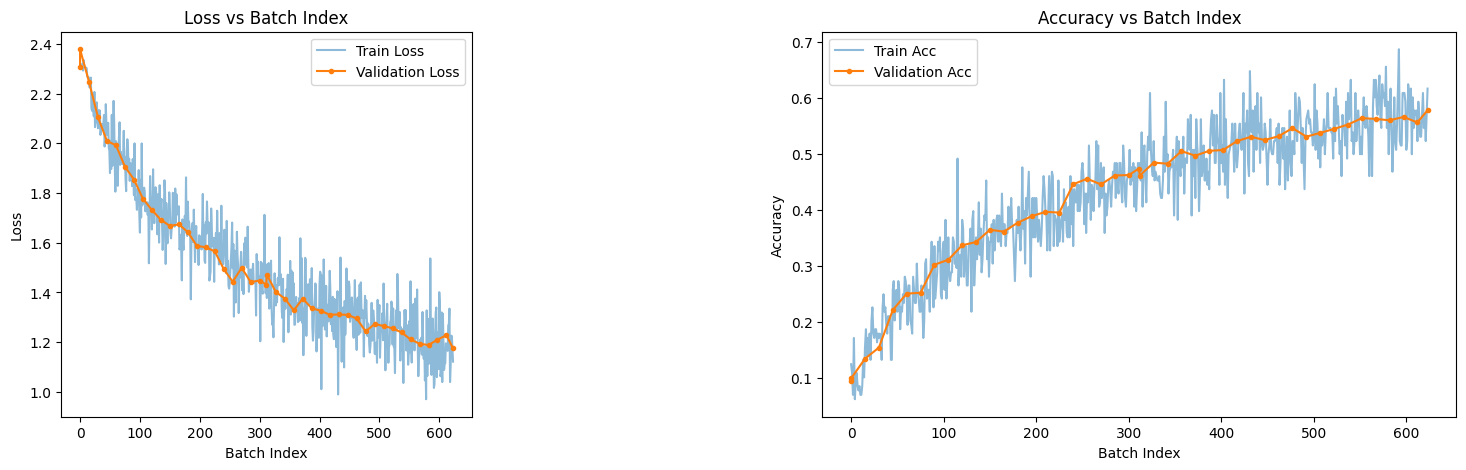

Epoch 3/10 strated in 1029.01 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 1.2262, Acc: 59.3750%, 进度:   128/40000
批次 0: Finished in 1029.53 seconds
批次 0 Val : Loss: 1.1777, Acc: 57.8400%
批次 0: Finished in 1044.02 seconds
批次 5 Train: Loss: 1.0172, Acc: 64.8438%, 进度:   768/40000
批次 5: Finished in 1046.44 seconds
批次 10 Train: Loss: 1.1931, Acc: 57.0312%, 进度:  1408/40000
批次 10: Finished in 1048.78 seconds
批次 15 Train: Loss: 1.2569, Acc: 53.9062%, 进度:  2048/40000
批次 15: Finished in 1051.13 seconds
批次 15 Val : Loss: 1.2220, Acc: 56.7600%
批次 15: Finished in 1063.95 seconds
批次 20 Train: Loss: 1.1881, Acc: 56.2500%, 进度:  2688/40000
批次 20: Finished in 1066.37 seconds
批次 25 Train: Loss: 1.1839, Acc: 56.2500%, 进度:  3328/40000
批次 25: Finished in 1068.81 seconds
批次 30 Train: Loss: 1.1157, Acc: 55.4688%, 进度:  3968/40000
批次 30: Finished in 1071.06 seconds
批次 30 Val : Loss: 1.1545, Acc: 58.4900%
批次 30: Finished in 1085.63 seconds
批次 35 Train: Loss: 1.2006, Acc: 57.0312%, 进度:  4608/40000
批次 35

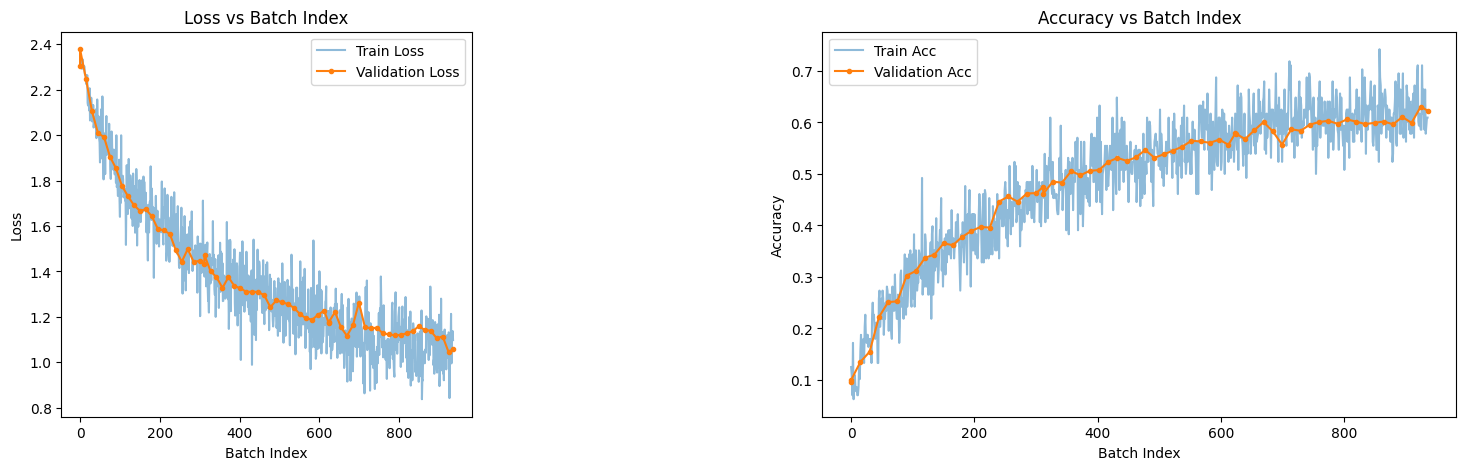

Epoch 4/10 strated in 1508.25 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 1.1435, Acc: 65.6250%, 进度:   128/40000
批次 0: Finished in 1508.75 seconds
批次 0 Val : Loss: 1.0494, Acc: 62.5300%
批次 0: Finished in 1523.23 seconds
批次 5 Train: Loss: 1.0769, Acc: 57.0312%, 进度:   768/40000
批次 5: Finished in 1525.56 seconds
批次 10 Train: Loss: 1.0508, Acc: 66.4062%, 进度:  1408/40000
批次 10: Finished in 1527.94 seconds
批次 15 Train: Loss: 0.8229, Acc: 69.5312%, 进度:  2048/40000
批次 15: Finished in 1530.72 seconds
批次 15 Val : Loss: 1.0359, Acc: 63.7100%
批次 15: Finished in 1548.92 seconds
批次 20 Train: Loss: 0.7175, Acc: 80.4688%, 进度:  2688/40000
批次 20: Finished in 1551.52 seconds
批次 25 Train: Loss: 1.0196, Acc: 61.7188%, 进度:  3328/40000
批次 25: Finished in 1553.93 seconds
批次 30 Train: Loss: 0.9092, Acc: 69.5312%, 进度:  3968/40000
批次 30: Finished in 1556.47 seconds
批次 30 Val : Loss: 1.0800, Acc: 62.4100%
批次 30: Finished in 1569.41 seconds
批次 35 Train: Loss: 1.0563, Acc: 59.3750%, 进度:  4608/40000
批次 35

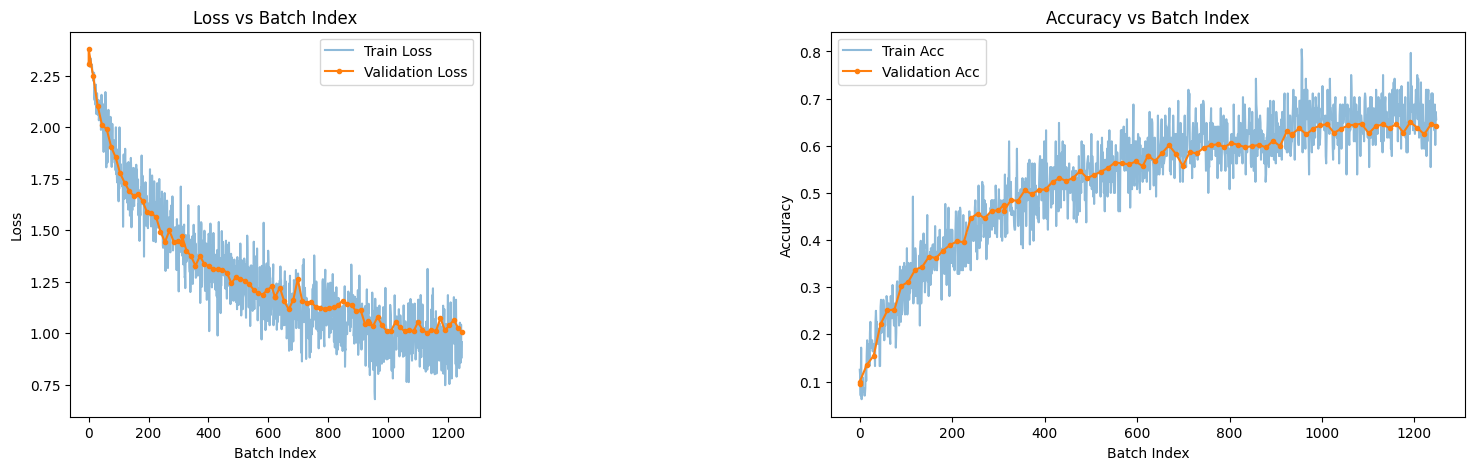

Epoch 5/10 strated in 1998.26 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 1.0043, Acc: 63.2812%, 进度:   128/40000
批次 0: Finished in 1998.79 seconds
批次 0 Val : Loss: 1.0059, Acc: 64.2300%
批次 0: Finished in 2016.98 seconds
批次 5 Train: Loss: 0.8320, Acc: 68.7500%, 进度:   768/40000
批次 5: Finished in 2019.72 seconds
批次 10 Train: Loss: 1.1034, Acc: 58.5938%, 进度:  1408/40000
批次 10: Finished in 2022.40 seconds
批次 15 Train: Loss: 0.8279, Acc: 71.8750%, 进度:  2048/40000
批次 15: Finished in 2025.21 seconds
批次 15 Val : Loss: 0.9810, Acc: 65.7900%
批次 15: Finished in 2043.43 seconds
批次 20 Train: Loss: 0.8739, Acc: 67.1875%, 进度:  2688/40000
批次 20: Finished in 2046.07 seconds
批次 25 Train: Loss: 0.7292, Acc: 72.6562%, 进度:  3328/40000
批次 25: Finished in 2048.49 seconds
批次 30 Train: Loss: 1.0698, Acc: 60.1562%, 进度:  3968/40000
批次 30: Finished in 2051.03 seconds
批次 30 Val : Loss: 1.0026, Acc: 65.7800%
批次 30: Finished in 2069.18 seconds
批次 35 Train: Loss: 0.9391, Acc: 67.1875%, 进度:  4608/40000
批次 35

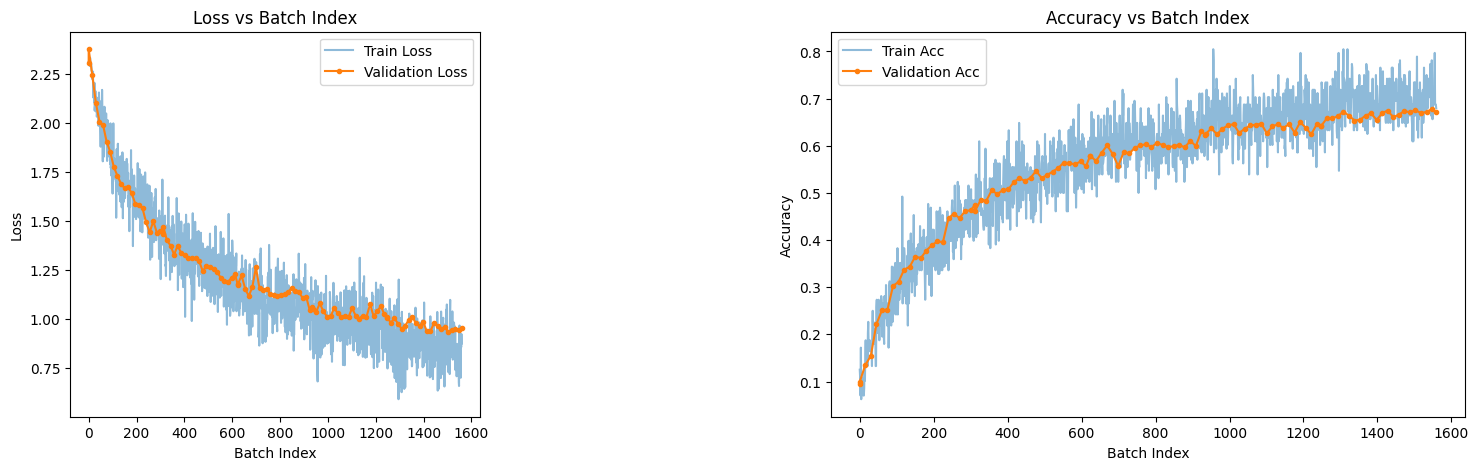

Epoch 6/10 strated in 2517.38 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 0.8272, Acc: 67.1875%, 进度:   128/40000
批次 0: Finished in 2517.90 seconds
批次 0 Val : Loss: 0.9616, Acc: 66.7100%
批次 0: Finished in 2536.28 seconds
批次 5 Train: Loss: 0.6760, Acc: 75.7812%, 进度:   768/40000
批次 5: Finished in 2539.03 seconds
批次 10 Train: Loss: 0.7312, Acc: 72.6562%, 进度:  1408/40000
批次 10: Finished in 2541.69 seconds
批次 15 Train: Loss: 0.8426, Acc: 68.7500%, 进度:  2048/40000
批次 15: Finished in 2544.36 seconds
批次 15 Val : Loss: 0.9238, Acc: 68.6500%
批次 15: Finished in 2558.92 seconds
批次 20 Train: Loss: 0.7797, Acc: 71.8750%, 进度:  2688/40000
批次 20: Finished in 2561.56 seconds
批次 25 Train: Loss: 0.6523, Acc: 72.6562%, 进度:  3328/40000
批次 25: Finished in 2564.22 seconds
批次 30 Train: Loss: 0.8201, Acc: 69.5312%, 进度:  3968/40000
批次 30: Finished in 2566.88 seconds
批次 30 Val : Loss: 0.9266, Acc: 68.1400%
批次 30: Finished in 2581.57 seconds
批次 35 Train: Loss: 0.7412, Acc: 71.8750%, 进度:  4608/40000
批次 35

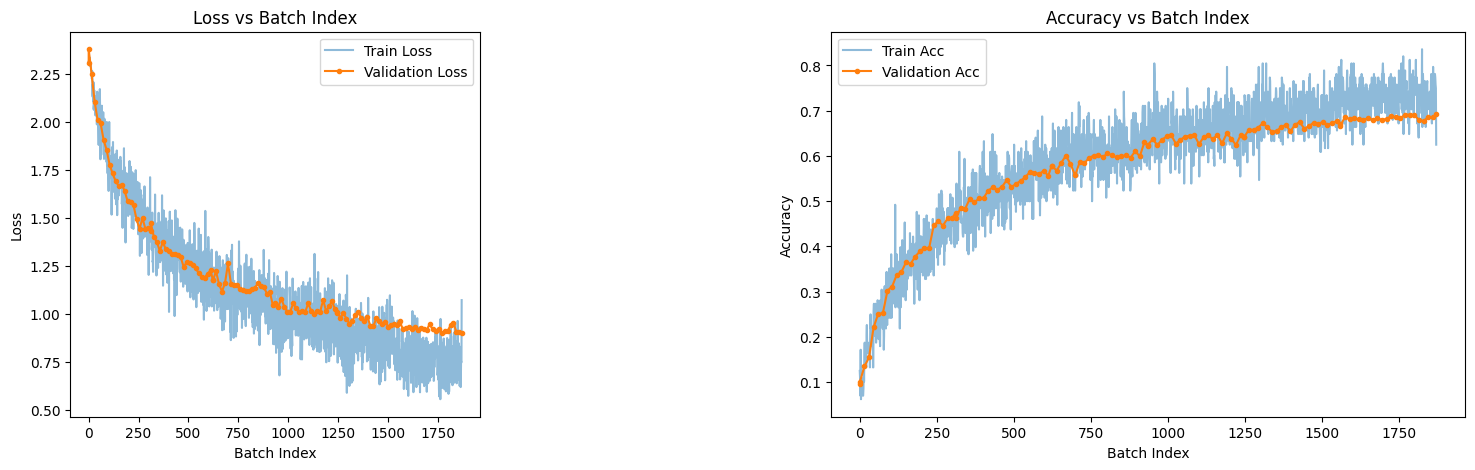

Epoch 7/10 strated in 3050.43 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 0.7073, Acc: 71.0938%, 进度:   128/40000
批次 0: Finished in 3050.95 seconds
批次 0 Val : Loss: 0.9023, Acc: 69.0700%
批次 0: Finished in 3065.55 seconds
批次 5 Train: Loss: 0.4971, Acc: 82.0312%, 进度:   768/40000
批次 5: Finished in 3067.96 seconds
批次 10 Train: Loss: 0.8246, Acc: 74.2188%, 进度:  1408/40000
批次 10: Finished in 3070.42 seconds
批次 15 Train: Loss: 0.7358, Acc: 73.4375%, 进度:  2048/40000
批次 15: Finished in 3072.85 seconds
批次 15 Val : Loss: 0.9293, Acc: 68.3200%
批次 15: Finished in 3087.35 seconds
批次 20 Train: Loss: 0.7238, Acc: 75.7812%, 进度:  2688/40000
批次 20: Finished in 3089.86 seconds
批次 25 Train: Loss: 0.5357, Acc: 76.5625%, 进度:  3328/40000
批次 25: Finished in 3092.26 seconds
批次 30 Train: Loss: 0.6364, Acc: 75.7812%, 进度:  3968/40000
批次 30: Finished in 3094.72 seconds
批次 30 Val : Loss: 0.8996, Acc: 69.4300%
批次 30: Finished in 3109.34 seconds
批次 35 Train: Loss: 0.7943, Acc: 71.8750%, 进度:  4608/40000
批次 35

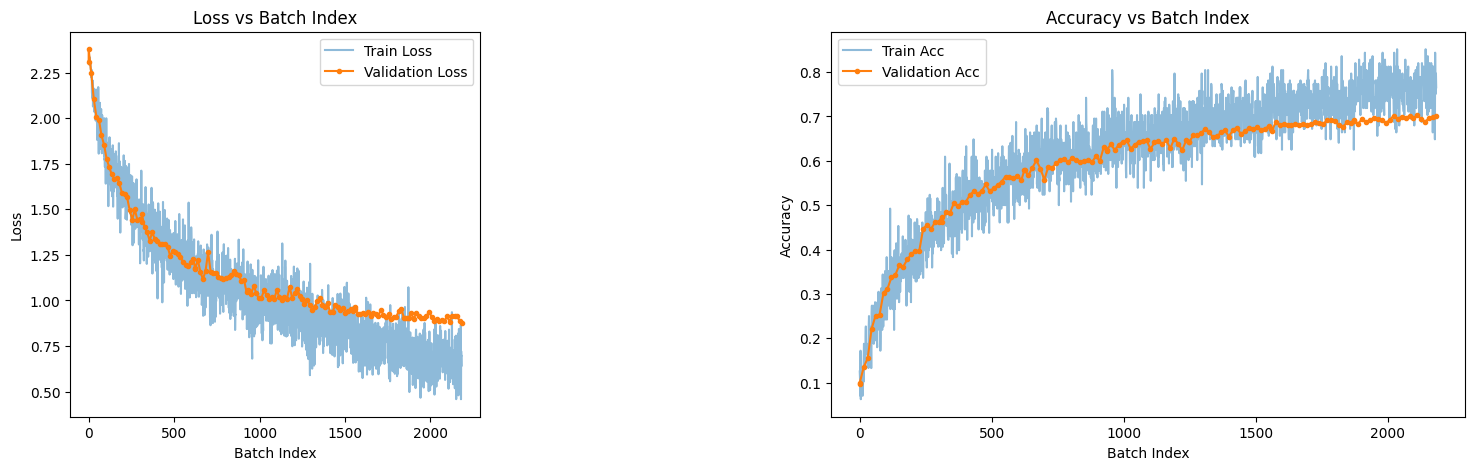

Epoch 8/10 strated in 3529.28 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 0.8191, Acc: 66.4062%, 进度:   128/40000
批次 0: Finished in 3529.81 seconds
批次 0 Val : Loss: 0.8770, Acc: 70.1400%
批次 0: Finished in 3548.08 seconds
批次 5 Train: Loss: 0.6425, Acc: 76.5625%, 进度:   768/40000
批次 5: Finished in 3550.73 seconds
批次 10 Train: Loss: 0.6243, Acc: 78.9062%, 进度:  1408/40000
批次 10: Finished in 3553.41 seconds
批次 15 Train: Loss: 0.5543, Acc: 85.1562%, 进度:  2048/40000
批次 15: Finished in 3556.09 seconds
批次 15 Val : Loss: 0.8779, Acc: 70.2800%
批次 15: Finished in 3570.60 seconds
批次 20 Train: Loss: 0.4945, Acc: 82.8125%, 进度:  2688/40000
批次 20: Finished in 3573.23 seconds
批次 25 Train: Loss: 0.6052, Acc: 72.6562%, 进度:  3328/40000
批次 25: Finished in 3575.87 seconds
批次 30 Train: Loss: 0.6331, Acc: 75.7812%, 进度:  3968/40000
批次 30: Finished in 3578.52 seconds
批次 30 Val : Loss: 0.8994, Acc: 70.3700%
批次 30: Finished in 3596.69 seconds
批次 35 Train: Loss: 0.4659, Acc: 85.9375%, 进度:  4608/40000
批次 35

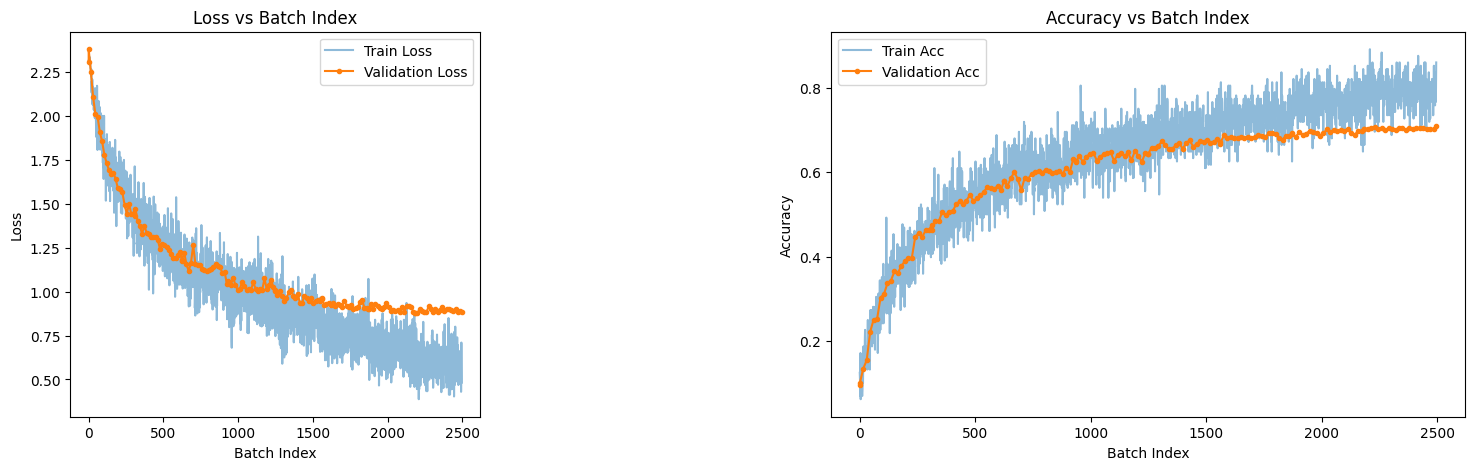

Epoch 9/10 strated in 4081.19 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 0.6032, Acc: 82.8125%, 进度:   128/40000
批次 0: Finished in 4081.73 seconds
批次 0 Val : Loss: 0.8830, Acc: 70.9000%
批次 0: Finished in 4100.16 seconds
批次 5 Train: Loss: 0.4607, Acc: 84.3750%, 进度:   768/40000
批次 5: Finished in 4102.97 seconds
批次 10 Train: Loss: 0.5834, Acc: 81.2500%, 进度:  1408/40000
批次 10: Finished in 4105.62 seconds
批次 15 Train: Loss: 0.5838, Acc: 78.1250%, 进度:  2048/40000
批次 15: Finished in 4108.40 seconds
批次 15 Val : Loss: 0.8887, Acc: 70.7400%
批次 15: Finished in 4126.74 seconds
批次 20 Train: Loss: 0.5119, Acc: 80.4688%, 进度:  2688/40000
批次 20: Finished in 4129.47 seconds
批次 25 Train: Loss: 0.5041, Acc: 82.0312%, 进度:  3328/40000
批次 25: Finished in 4132.21 seconds
批次 30 Train: Loss: 0.5370, Acc: 82.0312%, 进度:  3968/40000
批次 30: Finished in 4135.01 seconds
批次 30 Val : Loss: 0.8932, Acc: 71.1100%
批次 30: Finished in 4153.44 seconds
批次 35 Train: Loss: 0.5251, Acc: 79.6875%, 进度:  4608/40000
批次 35

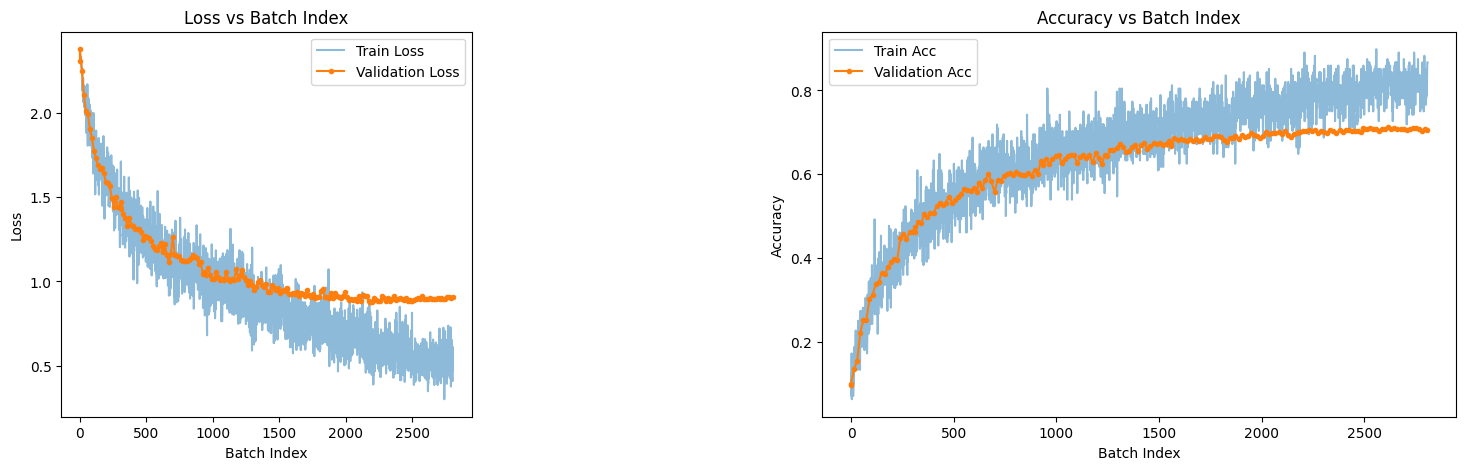

Epoch 10/10 strated in 4603.72 seconds
开始训练 - 总样本数: 40000
总批次数: 312
批次 0 Train: Loss: 0.6213, Acc: 77.3438%, 进度:   128/40000
批次 0: Finished in 4604.25 seconds
批次 0 Val : Loss: 0.9100, Acc: 70.5700%
批次 0: Finished in 4622.57 seconds
批次 5 Train: Loss: 0.4013, Acc: 84.3750%, 进度:   768/40000
批次 5: Finished in 4625.40 seconds
批次 10 Train: Loss: 0.3790, Acc: 85.9375%, 进度:  1408/40000
批次 10: Finished in 4628.03 seconds
批次 15 Train: Loss: 0.5229, Acc: 82.0312%, 进度:  2048/40000
批次 15: Finished in 4630.72 seconds
批次 15 Val : Loss: 0.8990, Acc: 70.7000%
批次 15: Finished in 4649.04 seconds
批次 20 Train: Loss: 0.3908, Acc: 82.0312%, 进度:  2688/40000
批次 20: Finished in 4651.62 seconds
批次 25 Train: Loss: 0.6028, Acc: 76.5625%, 进度:  3328/40000
批次 25: Finished in 4654.36 seconds
批次 30 Train: Loss: 0.4111, Acc: 82.8125%, 进度:  3968/40000
批次 30: Finished in 4656.94 seconds
批次 30 Val : Loss: 0.9000, Acc: 70.7000%
批次 30: Finished in 4671.51 seconds
批次 35 Train: Loss: 0.4961, Acc: 85.9375%, 进度:  4608/40000
批次 3

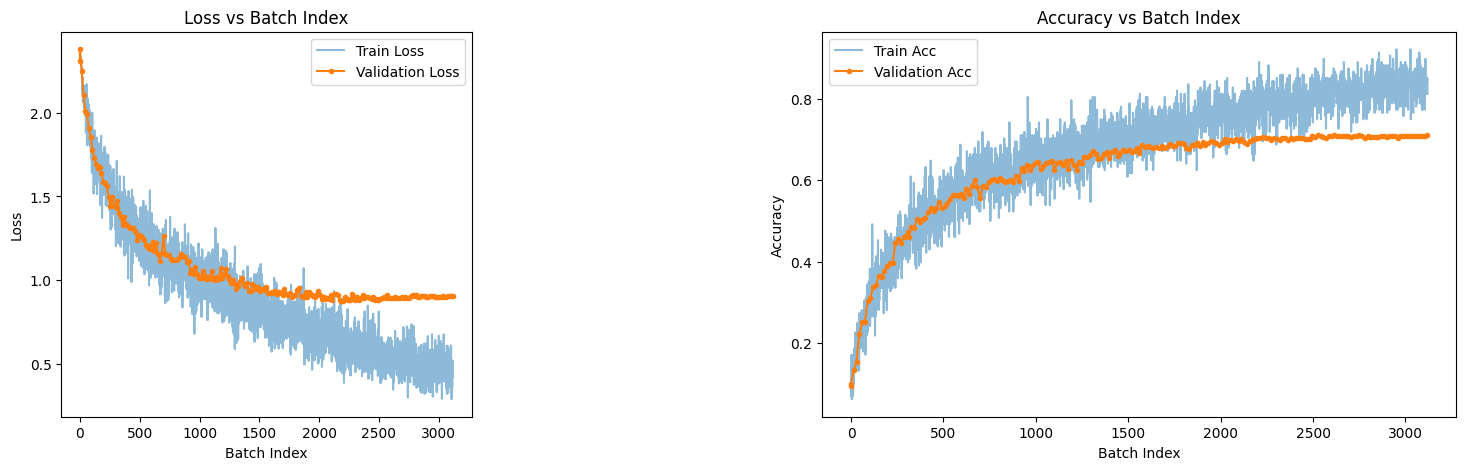

Training completed! Best accuracy: 71.05%


In [13]:
# 随机数种子：确保每次运行代码得到相同的结果
# 请同学把随机种子改成自己的学号，方便助教后期验证结果的真实性。
seed = 525031910002
# 例如：
# seed = 12345678
# activation 是一个字符串，指定了隐藏层使用的激活函数类型。常见的激活函数包括 'relu'（修正线性单元）、'tanh'（双曲正切）和 'sigmoid'（S形函数）。例如，activation='relu' 表示使用ReLU激活函数。
activation = 'relu'
# num_classes 是一个整数，表示分类任务中的类别数量。例如，对于CIFAR10数据集，num_classes=10，因为CIFAR10包含10个不同的类别。
num_classes = 10
# dropout_rate 是一个浮点数，表示在训练过程中应用的Dropout正则化的比率。Dropout是一种防止过拟合的技术，通过在训练过程中随机丢弃神经元来实现。例如，dropout_rate=0.1 表示每个神经元有10%的概率被丢弃。
dropout_rate = 0.2
# train_batch_size 是一个整数，表示在训练过程中每个批次中包含的样本数量。较大的批次大小可以加速训练，但可能需要更多的内存。例如，train_batch_size=64 表示每个批次包含64个样本。
train_batch_size: int = 128
# epochs 是一个整数，表示整个训练数据集要被训练的次数。每个epoch表示模型已经看过整个训练数据集一次。例如，epochs=10 表示模型将对整个训练数据集进行10次迭代。
epochs: int = 10
# learning_rate 是一个浮点数，表示模型在训练过程中调整参数的步长。较大的学习率可能导致训练不稳定，而较小的学习率可能导致训练过慢。例如，
learning_rate: float = 0.003
# weight_decay 是一个浮点数，表示L2正则化的强度。L2正则化通过在损失函数中添加模型参数的平方和来防止过拟合。例如，
weight_decay: float = 0.0003
# in_channels 是一个整数，表示输入图像的通道数。例如，对于CIFAR10数据集，in_channels=3
in_channels: int = 3
# conv_layers 是一个列表，定义了每个卷积层的输出通道数。例如，conv_layers=[32, 64] 表示有两个卷积层，第一层输出32个通道，第二层输出64个通道。
conv_layers: list = [64, 128,128,256]
# conv_layers: list = [4, 4]
# kernel_size 是一个整数，表示卷积核的大小。例如，kernel_size=3
kernel_size: int = 3
# fc_layers 是一个列表，定义了每个全连接层的输出维度。例如，fc_layers=[128, 64] 表示有两个全连接层，第一层输出128维，第二层输出64维。
fc_layers: list = [512, 128]
# fc_layers: list = [5, 5]

#ratio比率：训练集中用于训练的数据量/总数据量
#比率0.8表示50000张图片中有40000张用于训练，10000用于测试
ratio = 0.8

loader_dict = prepare_data_loader(path=Path(f"{ROOT_PATH}/training.pt"), ratio=ratio, train_batch_size=train_batch_size,)
train_loader = loader_dict["train"]
val_loader = loader_dict["val"]
# 增加一个 train 和 val 的图像示意图
train_sample = next(iter(train_loader))
val_sample = next(iter(val_loader))

show_sample_images(train_sample, "Train Sample Images")
show_sample_images(val_sample, "Validation Sample Images")
# print(f"Start Total Epoch: {epochs}")
model = controller(
    train_loader=train_loader,
    val_loader=val_loader,
    seed=seed,
    in_channels=in_channels,
    conv_layers=conv_layers,
    kernel_size=kernel_size,
    fc_layers=fc_layers,
    num_classes=num_classes,
    dropout_rate=dropout_rate,
    ratio = ratio,
    train_batch_size=train_batch_size,
    epochs=epochs,  
    learning_rate=learning_rate,
    weight_decay = weight_decay
)


In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
import os
def evaluater_with_dataloader_and_save(model, test_path, device, solution_path=None):
    """
    使用 val_dataloader 计算准确率并可选择保存预测结果
    
    参数:
    - model: 需要评估的模型
    - val_loader: 测试数据加载器
    - device: 计算设备 (CPU 或 GPU)
    - solution_path: 保存预测结果的路径(可选)
    
    返回:
    - accuracy: 模型在测试集上的准确率
    """
    model.eval()  # 设置为评估模式
    all_predictions = []
    test_dataset = torch.load(test_path)
    
    test_dataset = MyDataset(test_dataset, torch.ones(len(test_dataset), dtype=torch.long))  # 创建一个假的标签数组，实际不会使用
    test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=128, shuffle=False, pin_memory=True)
    all_ids = []
    with torch.no_grad():
        for batch_idx, (images, _) in enumerate(test_dataloader):
            images = images.to(device)
            logits = model(images)
            predictions = torch.argmax(logits, dim=1).cpu().numpy()
            all_predictions.extend(predictions)
            all_ids.extend(range(batch_idx * 128, batch_idx * 128 + len(predictions)))
    
    # 保存预测结果
    if solution_path is not None:
        predictions_df = pd.DataFrame({"ID": all_ids, "label": all_predictions})
        predictions_df.to_csv(solution_path, index=False)
        print(f'预测结果已保存至 {solution_path}')

os.makedirs('/personal/CIFAR10', exist_ok=True)
# test_dataloader = prepare_data_loader(path=Path(f"{ROOT_PATH}/test-shuffled-nolabel.pt"),train_batch_size=128, is_train=False)['test']
evaluater_with_dataloader_and_save(
    model,
    test_path=Path(f"{ROOT_PATH}/test-shuffled-nolabel.pt"),
    solution_path=Path("/personal/CIFAR10/submission.csv"),
    device = device
    )


/opt/miniconda/lib/python3.7/site-packages/ipykernel_launcher.py:65: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
预测结果已保存至 /personal/CIFAR10/submission.csv
